# IT3091 - Member 4 - IT23361690 - Gunathilake B.M.P


In [1]:
# Clone the latest project from GitHub
!git clone https://github.com/DTD-Wijesinghe/IT3091---Machine-Learning-Assignment.git
%cd /content/IT3091---Machine-Learning-Assignment

Cloning into 'IT3091---Machine-Learning-Assignment'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 131 (delta 48), reused 34 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 7.92 MiB | 4.34 MiB/s, done.
Resolving deltas: 100% (48/48), done.
/content/IT3091---Machine-Learning-Assignment


## Member 4 - Model training, evaluation and final output

In [2]:
!pip -q install openpyxl joblib

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

REPO_PATH = Path("/content/IT3091---Machine-Learning-Assignment")
PREPROCESSED_PATH = REPO_PATH / "Preprocessed Datasets"
PREPROCESSED_PATH.mkdir(parents=True, exist_ok=True)

FINAL_DATA_FILE = PREPROCESSED_PATH / "03_final_modelling_dataset.csv"

if not FINAL_DATA_FILE.exists():
    raise FileNotFoundError(
        "Member 3 final modelling dataset is missing. "
        "Make sure Member 3 pushed the file first."
    )

model_data = pd.read_csv(FINAL_DATA_FILE)

print("Loaded:", FINAL_DATA_FILE.name)
print("Shape:", model_data.shape)
display(model_data.head())

Loaded: 03_final_modelling_dataset.csv
Shape: (360, 19)


,District,Season,CropCategory,Crop,Year,Extent,Production,Yield_t_ha,Yield_IQR_Flag,AnchorMonth,AnchorDate,SeasonMeanTemp_C,SeasonTotalPrecip_mm,SeasonMeanWind_kmh,SeasonMeanSolar_MJm2,SeasonTotalET0_mm,WeatherDays,PrevMonthWholesalePrice_RsKg,NextMonthWholesalePrice_RsKg
0,National Total,Yala,Low Country Vegetable,Luffa,2012,1861.0,17053.0,9.163353,False,4,2012-04-01,26.729557,461.511111,19.387098,20.372622,722.928519,153.0,34.223333,53.8075
1,National Total,Maha,Low Country Vegetable,Luffa,2012,2840.0,25733.0,9.060915,False,9,2012-09-01,25.019881,1541.337037,14.031516,17.581104,790.763333,212.0,35.477500,59.0260
2,National Total,Yala,Low Country Vegetable,Luffa,2013,1985.0,17801.0,8.967758,False,4,2013-04-01,26.401065,603.770370,18.785476,19.653951,672.985926,153.0,48.970000,49.2650
3,National Total,Maha,Low Country Vegetable,Luffa,2013,3005.0,28598.0,9.516805,False,9,2013-09-01,25.089745,818.574074,15.617051,18.621454,854.841111,212.0,49.625000,41.2200
4,National Total,Yala,Low Country Vegetable,Luffa,2014,1881.0,16066.0,8.541201,False,4,2014-04-01,26.723844,600.807407,18.497434,20.152554,698.109630,153.0,51.710000,87.4350


In [3]:
# Save the exact dataset used for final model training
member4_data = PREPROCESSED_PATH / "04_final_modelling_dataset.csv"
model_data.to_csv(member4_data, index=False)

TARGETS = [
    "Yield_t_ha",
    "NextMonthWholesalePrice_RsKg"
]

FEATURES = [
    "Crop",
    "Season",
    "Year",
    "Extent",
    "SeasonMeanTemp_C",
    "SeasonTotalPrecip_mm",
    "SeasonMeanWind_kmh",
    "SeasonMeanSolar_MJm2",
    "SeasonTotalET0_mm",
    "PrevMonthWholesalePrice_RsKg"
]

X = model_data[FEATURES].copy()
y = model_data[TARGETS].copy()

print("X:", X.shape)
print("y:", y.shape)

X: (360, 10)
y: (360, 2)


In [4]:
train_mask = model_data["Year"].between(2012, 2019)
val_mask = model_data["Year"].between(2020, 2021)
test_mask = model_data["Year"].between(2022, 2023)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

if min(len(X_train), len(X_val), len(X_test)) == 0:
    raise ValueError("One data split is empty.")

Train: (237, 10)
Validation: (53, 10)
Test: (70, 10)


In [5]:
CAT_FEATURES = ["Crop", "Season"]
NUM_FEATURES = [
    c for c in FEATURES
    if c not in CAT_FEATURES
]

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

num_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_scaled = ColumnTransformer([
    ("cat", cat_pipe, CAT_FEATURES),
    ("num", num_scaled, NUM_FEATURES)
])

preprocess_tree = ColumnTransformer([
    ("cat", cat_pipe, CAT_FEATURES),
    ("num", num_tree, NUM_FEATURES)
])

In [6]:
models = {
    "Dummy Baseline": Pipeline([
        ("prep", preprocess_tree),
        ("model", MultiOutputRegressor(
            DummyRegressor(strategy="mean")
        ))
    ]),

    "Linear Regression": Pipeline([
        ("prep", preprocess_scaled),
        ("model", MultiOutputRegressor(
            LinearRegression()
        ))
    ]),

    "Random Forest": Pipeline([
        ("prep", preprocess_tree),
        ("model", MultiOutputRegressor(
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("prep", preprocess_tree),
        ("model", MultiOutputRegressor(
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_STATE
            )
        ))
    ])
}

print(list(models))

['Dummy Baseline', 'Linear Regression', 'Random Forest', 'Gradient Boosting']


In [7]:
def regression_metrics(y_true, pred):
    rows = {}

    for i, target in enumerate(TARGETS):
        rows[target] = {
            "MAE": mean_absolute_error(
                y_true.iloc[:, i],
                pred[:, i]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_true.iloc[:, i],
                    pred[:, i]
                )
            ),
            "R2": r2_score(
                y_true.iloc[:, i],
                pred[:, i]
            )
        }

    return rows


validation_rows = []
fitted_validation_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    metrics = regression_metrics(y_val, pred)

    fitted_validation_models[name] = model

    validation_rows.append({
        "Model": name,
        "Yield_MAE": metrics["Yield_t_ha"]["MAE"],
        "Yield_RMSE": metrics["Yield_t_ha"]["RMSE"],
        "Yield_R2": metrics["Yield_t_ha"]["R2"],
        "Price_MAE": metrics["NextMonthWholesalePrice_RsKg"]["MAE"],
        "Price_RMSE": metrics["NextMonthWholesalePrice_RsKg"]["RMSE"],
        "Price_R2": metrics["NextMonthWholesalePrice_RsKg"]["R2"]
    })

comparison = pd.DataFrame(validation_rows)

for c in [
    "Yield_MAE",
    "Yield_RMSE",
    "Price_MAE",
    "Price_RMSE"
]:
    comparison[c + "_Rank"] = comparison[c].rank(
        method="min",
        ascending=True
    )

for c in ["Yield_R2", "Price_R2"]:
    comparison[c + "_Rank"] = comparison[c].rank(
        method="min",
        ascending=False
    )

rank_cols = [
    c for c in comparison.columns
    if c.endswith("_Rank")
]

comparison["Balanced_Rank"] = (
    comparison[rank_cols].mean(axis=1)
)

comparison = comparison.sort_values(
    "Balanced_Rank"
).reset_index(drop=True)

display(comparison.round(4))

comparison.to_csv(
    REPO_PATH / "validation_model_comparison.csv",
    index=False
)

,Model,Yield_MAE,Yield_RMSE,Yield_R2,Price_MAE,Price_RMSE,Price_R2,Yield_MAE_Rank,Yield_RMSE_Rank,Price_MAE_Rank,Price_RMSE_Rank,Yield_R2_Rank,Price_R2_Rank,Balanced_Rank
0,Gradient Boosting,1.6268,2.3326,0.7897,43.6329,56.3775,0.0764,1.0,1.0,2.0,2.0,1.0,2.0,1.5000
1,Linear Regression,3.0283,3.8515,0.4267,46.8732,54.0558,0.1509,3.0,3.0,3.0,1.0,3.0,1.0,2.3333
2,Random Forest,1.7215,2.6314,0.7324,47.5231,60.1521,-0.0514,2.0,2.0,4.0,3.0,2.0,3.0,2.6667
3,Dummy Baseline,3.8860,5.0990,-0.0048,41.2208,61.5080,-0.0994,4.0,4.0,1.0,4.0,4.0,4.0,3.5000


In [8]:
BEST_MODEL_NAME = comparison.loc[0, "Model"]

print("Selected model:", BEST_MODEL_NAME)

X_trainval = pd.concat(
    [X_train, X_val]
).sort_index()

y_trainval = pd.concat(
    [y_train, y_val]
).sort_index()

final_model = models[BEST_MODEL_NAME]
final_model.fit(X_trainval, y_trainval)

test_pred = final_model.predict(X_test)
test_metrics = regression_metrics(
    y_test,
    test_pred
)

print("FINAL TEST METRICS")
print(json.dumps(test_metrics, indent=2))

Selected model: Gradient Boosting
FINAL TEST METRICS
{
  "Yield_t_ha": {
    "MAE": 1.3199746269917665,
    "RMSE": 1.746767860422914,
    "R2": 0.8524485687844028
  },
  "NextMonthWholesalePrice_RsKg": {
    "MAE": 87.88016524841888,
    "RMSE": 114.13150254429121,
    "R2": -0.10430329221925283
  }
}


In [9]:
final_results = pd.DataFrame({
    "Actual_Yield_t_ha":
        y_test["Yield_t_ha"].values,

    "Predicted_Yield_t_ha":
        test_pred[:, 0],

    "Actual_NextMonthPrice_RsKg":
        y_test["NextMonthWholesalePrice_RsKg"].values,

    "Predicted_NextMonthPrice_RsKg":
        test_pred[:, 1]
})

display(final_results.head(20))

final_results.to_csv(
    REPO_PATH / "final_test_predictions.csv",
    index=False
)

,Actual_Yield_t_ha,Predicted_Yield_t_ha,Actual_NextMonthPrice_RsKg,Predicted_NextMonthPrice_RsKg
0,10.847590,10.832479,232.869841,126.235488
1,10.870996,10.509833,190.800000,153.246659
2,10.963093,9.266280,247.600000,100.701582
3,10.318842,10.948798,205.000000,107.418023
4,9.910431,9.800000,178.000000,98.830368
5,8.936834,9.426035,105.200000,130.186965
6,9.324213,8.867346,142.200000,134.184948
7,8.712354,9.562526,136.400000,94.481469
8,11.106348,13.071761,369.600000,213.943479
9,10.942310,10.842945,349.800000,260.472372


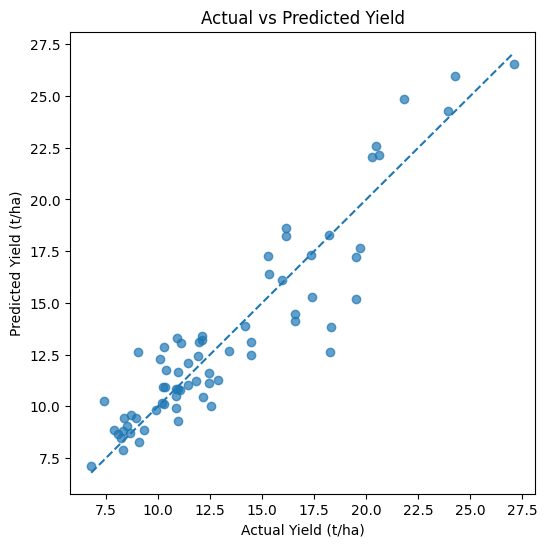

In [10]:
plt.figure(figsize=(6, 6))

plt.scatter(
    final_results["Actual_Yield_t_ha"],
    final_results["Predicted_Yield_t_ha"],
    alpha=0.7
)

lo = min(
    final_results["Actual_Yield_t_ha"].min(),
    final_results["Predicted_Yield_t_ha"].min()
)

hi = max(
    final_results["Actual_Yield_t_ha"].max(),
    final_results["Predicted_Yield_t_ha"].max()
)

plt.plot([lo, hi], [lo, hi], "--")
plt.xlabel("Actual Yield (t/ha)")
plt.ylabel("Predicted Yield (t/ha)")
plt.title("Actual vs Predicted Yield")
plt.show()

In [11]:
SEASON_ANCHOR_MONTH = {
    "Yala": 4,
    "Maha": 9
}

DATA_SOURCES = {
    "production": "researchData.xlsx",
    "weather": "weatherData.csv + locationData.csv",
    "weekly_price": "Weekly Average Retail Prices of Vegi - 2012 to 2025.xlsx"
}

joblib.dump(
    final_model,
    REPO_PATH / "final_multioutput_model.joblib"
)

metadata = {
    "selected_model": BEST_MODEL_NAME,
    "features": FEATURES,
    "targets": TARGETS,
    "train_years": [2012, 2019],
    "validation_years": [2020, 2021],
    "test_years": [2022, 2023],
    "season_anchor_month": SEASON_ANCHOR_MONTH,
    "random_state": RANDOM_STATE,
    "test_metrics": test_metrics,
    "data_sources": DATA_SOURCES
}

with open(
    REPO_PATH / "model_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata, f, indent=2)

print("Final model saved.")

Final model saved.


In [12]:
yield_reference = (
    model_data[
        model_data["Year"] <= 2021
    ]
    .groupby("Crop")["Yield_t_ha"]
    .median()
    .to_dict()
)


def predict_plan(
    crop,
    season,
    year,
    planned_extent_ha,
    mean_temp_c,
    total_precip_mm,
    mean_wind_kmh,
    mean_solar_mjm2,
    total_et0_mm,
    prev_month_price_rs_kg
):
    row = pd.DataFrame([{
        "Crop": crop,
        "Season": season,
        "Year": year,
        "Extent": planned_extent_ha,
        "SeasonMeanTemp_C": mean_temp_c,
        "SeasonTotalPrecip_mm": total_precip_mm,
        "SeasonMeanWind_kmh": mean_wind_kmh,
        "SeasonMeanSolar_MJm2": mean_solar_mjm2,
        "SeasonTotalET0_mm": total_et0_mm,
        "PrevMonthWholesalePrice_RsKg":
            prev_month_price_rs_kg
    }])

    pred = final_model.predict(row)[0]

    pred_yield = max(0.0, float(pred[0]))
    pred_price = max(0.0, float(pred[1]))

    expected_production = (
        pred_yield * planned_extent_ha
    )

    price_change_pct = (
        (pred_price - prev_month_price_rs_kg)
        / prev_month_price_rs_kg
        * 100
        if prev_month_price_rs_kg > 0
        else np.nan
    )

    crop_median = yield_reference.get(
        crop,
        np.nan
    )

    yield_good = (
        np.isnan(crop_median)
        or pred_yield >= crop_median
    )

    if price_change_pct >= 5 and yield_good:
        recommendation = (
            "Favourable signal: expected yield is reasonable/high "
            "and next-month price is predicted to rise."
        )

    elif price_change_pct <= -5 and yield_good:
        recommendation = (
            "Caution: expected yield is reasonable/high but "
            "next-month price may fall."
        )

    elif price_change_pct >= 5 and not yield_good:
        recommendation = (
            "Mixed signal: price may improve, but predicted "
            "yield is below the historical median."
        )

    else:
        recommendation = (
            "Neutral/cautious signal: check costs, local "
            "conditions and market information."
        )

    return {
        "Predicted Yield (t/ha)":
            round(pred_yield, 2),

        "Expected Production (tonnes)":
            round(expected_production, 2),

        "Predicted Next-Month Wholesale Price (Rs/kg)":
            round(pred_price, 2),

        "Predicted Price Change (%)":
            None if np.isnan(price_change_pct)
            else round(price_change_pct, 2),

        "Recommendation":
            recommendation
    }

In [13]:
example_index = X_test.index[0]
example = X_test.loc[example_index]

result = predict_plan(
    crop=example["Crop"],
    season=example["Season"],
    year=int(example["Year"]),
    planned_extent_ha=float(example["Extent"]),
    mean_temp_c=float(example["SeasonMeanTemp_C"]),
    total_precip_mm=float(example["SeasonTotalPrecip_mm"]),
    mean_wind_kmh=float(example["SeasonMeanWind_kmh"]),
    mean_solar_mjm2=float(example["SeasonMeanSolar_MJm2"]),
    total_et0_mm=float(example["SeasonTotalET0_mm"]),
    prev_month_price_rs_kg=float(
        example["PrevMonthWholesalePrice_RsKg"]
    )
)

print("FINAL MODEL OUTPUT")
print(json.dumps(result, indent=2))

FINAL MODEL OUTPUT
{
  "Predicted Yield (t/ha)": 10.83,
  "Expected Production (tonnes)": 19261.23,
  "Predicted Next-Month Wholesale Price (Rs/kg)": 126.24,
  "Predicted Price Change (%)": -8.74,
  "Recommendation": "Caution: expected yield is reasonable/high but next-month price may fall."
}


In [ ]:
# Save this executed notebook and push this member's work to GitHub
from getpass import getpass
from google.colab import _message
import subprocess

MEMBER_NAME = 'Gunathilake B.M.P'
NOTEBOOK_NAME = '04_IT23361690_Gunathilake_BMP_Final_Model.ipynb'
FILES_TO_ADD = ['Preprocessed Datasets/04_final_modelling_dataset.csv', 'validation_model_comparison.csv', 'final_test_predictions.csv', 'final_multioutput_model.joblib', 'model_metadata.json']

# Save the current Colab notebook inside the cloned repository
current_notebook = _message.blocking_request("get_ipynb", request="", timeout_sec=10)
notebook_path = REPO_PATH / NOTEBOOK_NAME

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(current_notebook["ipynb"], f, ensure_ascii=False, indent=1)

print("Saved notebook:", notebook_path.name)

# Git identity
github_email = input("GitHub email: ").strip()
github_username = input("GitHub username: ").strip()
github_token = getpass("GitHub Personal Access Token: ")

subprocess.run(["git", "config", "user.name", MEMBER_NAME], cwd=REPO_PATH, check=True)
subprocess.run(["git", "config", "user.email", github_email], cwd=REPO_PATH, check=True)

# Add notebook and this member's output files
for item in [NOTEBOOK_NAME] + FILES_TO_ADD:
    subprocess.run(["git", "add", item], cwd=REPO_PATH, check=True)

status = subprocess.run(
    ["git", "status", "--short"],
    cwd=REPO_PATH,
    text=True,
    capture_output=True,
    check=True
)
print(status.stdout)

# Commit only when there is something new
if status.stdout.strip():
    subprocess.run(
        ["git", "commit", "-m", 'Member 4: Add final model training evaluation and output'],
        cwd=REPO_PATH,
        check=True
    )
else:
    print("Nothing new to commit.")

# Secure GitHub authentication for this push
askpass = Path("/tmp/git_askpass.sh")
askpass.write_text(
    '#!/bin/sh\n'
    'case "$1" in\n'
    '  *Username*) echo "$GITHUB_USERNAME" ;;\n'
    '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
    'esac\n'
)
askpass.chmod(0o700)

env = os.environ.copy()
env["GITHUB_USERNAME"] = github_username
env["GITHUB_TOKEN"] = github_token
env["GIT_ASKPASS"] = str(askpass)

result = subprocess.run(
    ["git", "push", "origin", "main"],
    cwd=REPO_PATH,
    env=env,
    text=True,
    capture_output=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("Push failed. Check the GitHub username, token and repository permission.")

print("Push completed.")